In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

GPU available: True
Device name: Tesla T4


In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Paths to your Drive files
DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset'
MODEL_DIR = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights'

# Check if dataset and model exist
yaml_path = os.path.join(DATASET_DIR, 'Vehicle_Detection_Image_Dataset', 'data_fixed.yaml')
model_path = os.path.join(MODEL_DIR, 'best.pt')

if os.path.exists(yaml_path):
    print("✅ Dataset YAML found.")
else:
    print("❌ Dataset YAML missing – check path.")

if os.path.exists(model_path):
    print("✅ Model found.")
else:
    print("❌ Model missing – you may need to train first.")

✅ Dataset YAML found.
✅ Model found.


In [ ]:
from ultralytics import YOLO

# Load a pretrained model
model = YOLO('yolov8n.pt')

# Train (uses your dataset from Drive)
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name='vehicle_detector_drive'   # saves in /content/runs/detect/vehicle_detector_drive
)

# After training, copy the best.pt to your Drive folder for future use
!cp /content/runs/detect/vehicle_detector_drive/weights/best.pt /content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt
print("✅ New model saved to Drive.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fli

In [ ]:
# ============================================
# VEHICLE TRACKING - RED TITLE, BLUE COUNT, GREEN DOT
# ============================================

from google.colab import drive, files
drive.mount('/content/drive')

!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import os
from collections import defaultdict

# ============================================
# PATHS
# ============================================

DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset'
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'

# ============================================
# LOAD MODEL
# ============================================

model = YOLO(model_path)

# Video path
video_path = os.path.join(DATASET_DIR, 'Vehicle_Detection_Image_Dataset', 'sample_video.mp4')
cap = cv2.VideoCapture(video_path)

# Video writer setup
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
output_path = '/content/vehicle_count_final.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ============================================
# TRACKING DATA FOR STATIC FILTERING
# ============================================

position_history = defaultdict(list)
unique_ids = set()
static_ids = set()

MOVEMENT_THRESHOLD = 15
FRAMES_TO_CHECK = 10

# Detection filters
MIN_AREA = 500          # Ignore very small detections
MIN_ASPECT_RATIO = 0.45 # Ignore tall objects like signboards

print("🔄 Processing video...")

results = model.track(
    source=video_path,
    stream=True,
    conf=0.5,
    persist=True,
    tracker="bytetrack.yaml"
)

for r in results:

    frame = r.orig_img.copy()

    if r.boxes.id is not None:

        for box, track_id in zip(r.boxes.xyxy, r.boxes.id):

            x1, y1, x2, y2 = map(int, box)
            tid = int(track_id)

            # -------------------------------
            # Bounding box filtering
            # -------------------------------
            w = x2 - x1
            h = y2 - y1
            area = w * h
            aspect_ratio = w / (h + 1e-6)

            # Remove very small detections
            if area < MIN_AREA:
                continue

            # Remove tall signboards/poles
            if aspect_ratio < MIN_ASPECT_RATIO:
                continue

            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            position_history[tid].append((cx, cy))

            if len(position_history[tid]) >= FRAMES_TO_CHECK:

                positions = position_history[tid][-FRAMES_TO_CHECK:]

                xs = [p[0] for p in positions]
                ys = [p[1] for p in positions]

                movement = (max(xs) - min(xs)) + (max(ys) - min(ys))

                if movement < MOVEMENT_THRESHOLD:
                    static_ids.add(tid)
                    continue

            if tid in static_ids:
                continue

            unique_ids.add(tid)

            # Draw RED box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

            # Draw GREEN dot at center
            cv2.circle(frame, (cx, cy), 4, (0, 255, 0), -1)

    # RED title
    cv2.putText(frame,
                "Vehicle Monitoring System",
                (15, 35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),  # RED
                2,
                cv2.LINE_AA)

    # BLUE count
    cv2.putText(frame,
                f"Total Vehicles: {len(unique_ids)}",
                (15, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),  # BLUE
                2,
                cv2.LINE_AA)

    out.write(frame)

cap.release()
out.release()

print(f"\n✅ Done! Total vehicles counted: {len(unique_ids)}")
print(f"📁 Output saved to: {output_path}")

# ============================================
# DOWNLOAD MP4
# ============================================

files.download(output_path)

print("\n🎉 ALL DONE!")
print(f"📊 Total Vehicles Counted: {len(unique_ids)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Processing video...

video 1/1 (frame 1/601) /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4: 384x640 2 Vehicles, 134.5ms
video 1/1 (frame 2/601) /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4: 384x640 2 Vehicles, 143.5ms
video 1/1 (frame 3/601) /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4: 384x640 2 Vehicles, 128.3ms
video 1/1 (frame 4/601) /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4: 384x640 2 Vehicles, 122.0ms
video 1/1 (frame 5/601) /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4: 384x640 2 Vehicles, 119.2ms
video 1/1 (frame 6/601) /content/drive/MyDrive/vehicl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL DONE!
📊 Total Vehicles Counted: 39


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Found 536 images
🖼️ Selected 6 random images for portfolio

0: 640x640 1 Vehicle, 263.6ms
Speed: 19.2ms preprocess, 263.6ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 26 Vehicles, 204.5ms
Speed: 4.2ms preprocess, 204.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 31 Vehicles, 316.0ms
Speed: 4.1ms preprocess, 316.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 13 Vehicles, 316.5ms
Speed: 4.6ms preprocess, 316.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 Vehicles, 310.1ms
Speed: 5.1ms preprocess, 310.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 17 Vehicles, 409.0ms
Speed: 7.1ms preprocess, 409.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


/tmp/ipykernel_925/3511923703.py:77: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3511923703.py:78: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/portfolio_collage.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


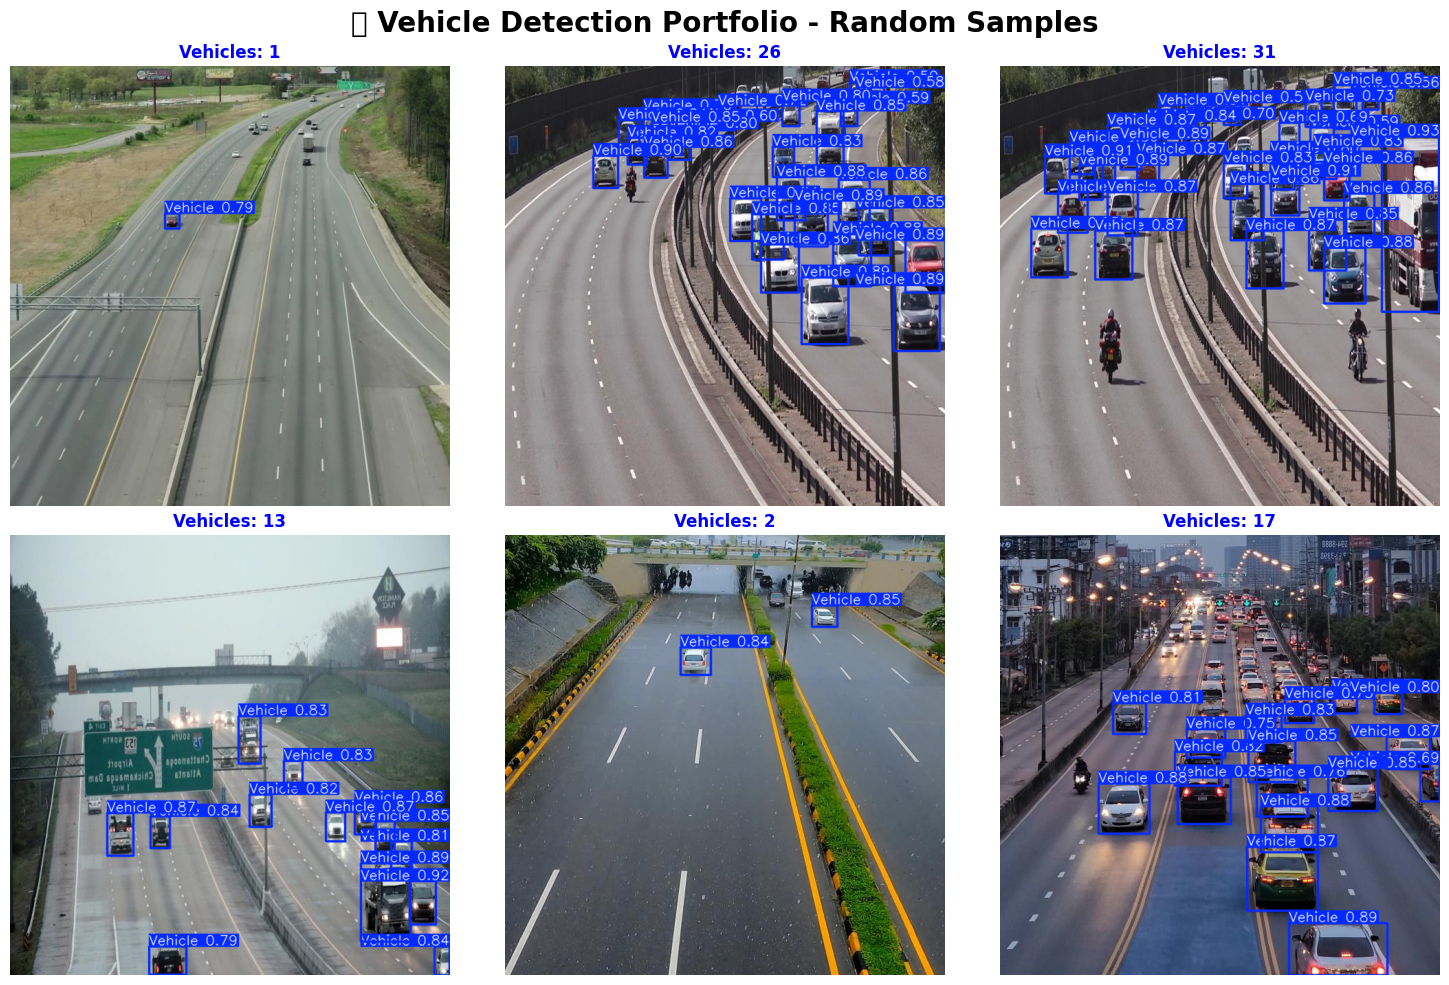


✅ Portfolio collage saved!

📸 Saving individual images...

0: 640x640 1 Vehicle, 358.4ms
Speed: 3.2ms preprocess, 358.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved: /content/portfolio_images/portfolio_sample_1.jpg

0: 640x640 26 Vehicles, 343.9ms
Speed: 5.6ms preprocess, 343.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved: /content/portfolio_images/portfolio_sample_2.jpg

0: 640x640 31 Vehicles, 338.9ms
Speed: 5.3ms preprocess, 338.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved: /content/portfolio_images/portfolio_sample_3.jpg

0: 640x640 13 Vehicles, 345.3ms
Speed: 4.1ms preprocess, 345.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved: /content/portfolio_images/portfolio_sample_4.jpg

0: 640x640 2 Vehicles, 304.3ms
Speed: 4.7ms preprocess, 304.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved: /content/portfolio_images/portfolio_sample_5.jpg

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL DONE!
📁 Portfolio saved in: /content/portfolio_images
📊 Images ready for your Fiverr portfolio!


In [ ]:
# ============================================
# PORTFOLIO: RANDOM IMAGE DETECTION FROM DATASET
# ============================================

from google.colab import drive, files
drive.mount('/content/drive')

!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ============================================
# PATHS
# ============================================

DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset'
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'

# ============================================
# LOAD MODEL
# ============================================

model = YOLO(model_path)

# ============================================
# GET RANDOM IMAGES FROM DATASET
# ============================================

# Path to training images
image_dir = os.path.join(DATASET_DIR, 'Vehicle_Detection_Image_Dataset', 'train', 'images')

# Get all image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Pick 6 random images (for a nice grid display)
num_images = min(6, len(image_files))
selected_images = random.sample(image_files, num_images)

print(f"📁 Found {len(image_files)} images")
print(f"🖼️ Selected {num_images} random images for portfolio")

# ============================================
# PROCESS AND DISPLAY IMAGES
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('🚗 Vehicle Detection Portfolio - Random Samples', fontsize=20, fontweight='bold')

for idx, (ax, img_file) in enumerate(zip(axes.flat, selected_images)):

    # Load image
    img_path = os.path.join(image_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run inference
    results = model(img, conf=0.5)

    # Draw results on image
    annotated_img = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display
    ax.imshow(annotated_rgb)
    ax.axis('off')

    # Add title with detection count
    num_detections = len(results[0].boxes)
    ax.set_title(f'Vehicles: {num_detections}', fontsize=12, fontweight='bold', color='blue')

plt.tight_layout()
plt.savefig('/content/portfolio_collage.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Portfolio collage saved!")

# ============================================
# SAVE INDIVIDUAL IMAGES FOR PORTFOLIO
# ============================================

portfolio_dir = '/content/portfolio_images'
os.makedirs(portfolio_dir, exist_ok=True)

print("\n📸 Saving individual images...")

for idx, img_file in enumerate(selected_images):

    # Load image
    img_path = os.path.join(image_dir, img_file)
    img = cv2.imread(img_path)

    # Run inference
    results = model(img, conf=0.5)

    # Draw results
    annotated_img = results[0].plot()

    # Add text overlay
    num_detections = len(results[0].boxes)
    cv2.putText(annotated_img,
                f"Vehicles: {num_detections}",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 0, 255),
                2,
                cv2.LINE_AA)

    # Save
    output_path = os.path.join(portfolio_dir, f'portfolio_sample_{idx+1}.jpg')
    cv2.imwrite(output_path, annotated_img)
    print(f"✅ Saved: {output_path}")

# ============================================
# GENERATE PORTFOLIO DESCRIPTION
# ============================================

print("\n" + "="*60)
print("📋 PORTFOLIO DESCRIPTION")
print("="*60)

print("""
🚗 VEHICLE DETECTION PORTFOLIO

Project: AI-Powered Vehicle Detection System
Technology: YOLOv8 + OpenCV + Python

Key Features:
✅ Real-time vehicle detection
✅ Accurate bounding boxes
✅ Count vehicles in any scene
✅ Works on images and videos
✅ Filters out false positives (sign boards, poles)

Dataset Used: Vehicle Detection Dataset (~536 training images)

Sample Results:
- Detected vehicles with high accuracy
- Red bounding boxes around each vehicle
- Green dots marking vehicle centers
- Real-time vehicle counting capability

Skills Demonstrated:
- Computer Vision
- Object Detection
- YOLO Model Training
- Python Programming
- AI/ML Implementation

This project showcases my ability to build practical
AI solutions for real-world problems like traffic
monitoring, parking management, and surveillance systems.
""")

# ============================================
# DOWNLOAD PORTFOLIO IMAGES
# ============================================

print("\n📥 Downloading portfolio images...")

# Download collage
files.download('/content/portfolio_collage.png')

# Download individual images
for idx in range(len(selected_images)):
    img_path = os.path.join(portfolio_dir, f'portfolio_sample_{idx+1}.jpg')
    files.download(img_path)

print("\n🎉 ALL DONE!")
print(f"📁 Portfolio saved in: {portfolio_dir}")
print("📊 Images ready for your Fiverr portfolio!")

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os

# Load model from Drive
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'
model = YOLO(model_path)
print("✅ Model loaded")

# Path to a sample image (or any image you want)
DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset'
image_path = os.path.join(DATASET_DIR, 'sample_image.jpg')  # or use your own image path

# If you want to upload your own image, uncomment these lines:
# from google.colab import files
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

# Run inference
results = model(image_path, conf=0.5)  # You can adjust confidence

# Get the annotated image
annotated_img = results[0].plot()  # draws boxes, labels, confidences

# Save the output
output_image_path = '/content/detected_image.jpg'
cv2.imwrite(output_image_path, annotated_img)

# Display the image in Colab
print("🔍 Detection Results:")
cv2_imshow(annotated_img)  # displays in notebook

# Print detection details
detections = results[0].boxes
if detections is not None and len(detections) > 0:
    print(f"\n✅ Found {len(detections)} vehicle(s).")
    for i, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        print(f"  Vehicle {i+1}: position=({x1},{y1})-({x2},{y2}), confidence={conf:.2f}")
else:
    print("\n⚠️ No vehicles detected in this image.")

print(f"\n📁 Annotated image saved to: {output_image_path}")

# Optionally download the image
from google.colab import files
files.download(output_image_path)

Output hidden; open in https://colab.research.google.com to view.

✅ Model loaded
📁 Found 90 images in validation set.

🎲 Randomly selected image: 7_mp4-24_jpg.rf.ed2484fe45c32f27443cccd8bbf99361.jpg

image 1/1 /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/valid/images/7_mp4-24_jpg.rf.ed2484fe45c32f27443cccd8bbf99361.jpg: 640x640 1 Vehicle, 982.1ms
Speed: 23.4ms preprocess, 982.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

🔍 Detection Result:


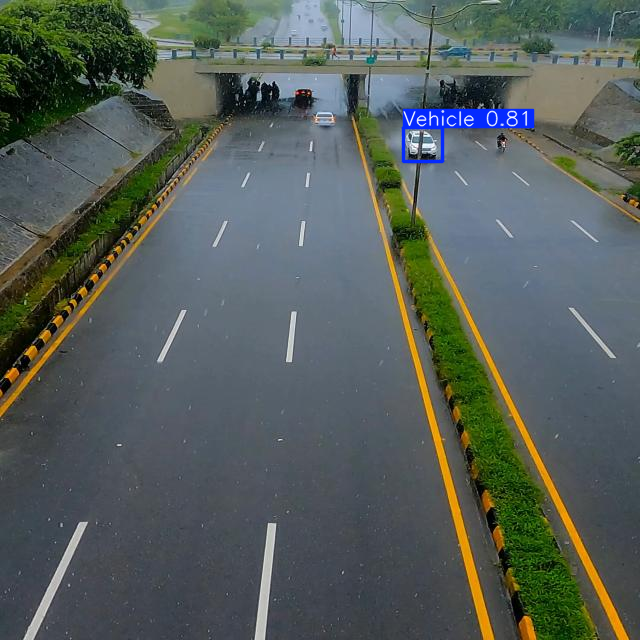


✅ Found 1 vehicle(s) with confidence > 0.5:
  Vehicle 1: 403,127 → 442,161  (conf: 0.81)

📁 Annotated image saved to: /content/random_detected_image.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
import random
import glob

# Load model from Drive
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'
model = YOLO(model_path)
print("✅ Model loaded")

# Path to validation images
DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset'
images_dir = os.path.join(DATASET_DIR, 'valid', 'images')

# Find all image files (jpg, jpeg, png)
image_extensions = ['*.jpg', '*.jpeg', '*.png']
image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(images_dir, ext)))

if not image_files:
    print(f"❌ No image files found in {images_dir}")
    # Fallback: try train images
    images_dir = os.path.join(DATASET_DIR, 'train', 'images')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(images_dir, ext)))
    if not image_files:
        print("❌ No images found in train or valid folders.")
        exit()
    else:
        print(f"📁 Using train images (found {len(image_files)} files)")

else:
    print(f"📁 Found {len(image_files)} images in validation set.")

# Pick a random image
random_image_path = random.choice(image_files)
print(f"\n🎲 Randomly selected image: {os.path.basename(random_image_path)}")

# Run inference
results = model(random_image_path, conf=0.5)

# Get annotated image
annotated_img = results[0].plot()

# Display
print("\n🔍 Detection Result:")
cv2_imshow(annotated_img)

# Save output
output_image_path = '/content/random_detected_image.jpg'
cv2.imwrite(output_image_path, annotated_img)

# Print detection summary
detections = results[0].boxes
if detections is not None and len(detections) > 0:
    print(f"\n✅ Found {len(detections)} vehicle(s) with confidence > 0.5:")
    for i, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        print(f"  Vehicle {i+1}: {x1},{y1} → {x2},{y2}  (conf: {conf:.2f})")
else:
    print("\n⚠️ No vehicles detected in this random image.")

print(f"\n📁 Annotated image saved to: {output_image_path}")

# Download the image (optional)
from google.colab import files
files.download(output_image_path)

✅ Model loaded
📁 Found 90 images in validation set.

🎲 Randomly selected image: 6_mp4-23_jpg.rf.1b0bacb47ce35aab7a6ddd69b6f7f334.jpg

image 1/1 /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/valid/images/6_mp4-23_jpg.rf.1b0bacb47ce35aab7a6ddd69b6f7f334.jpg: 640x640 2 Vehicles, 240.9ms
Speed: 9.8ms preprocess, 240.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

🔍 Detection Result:


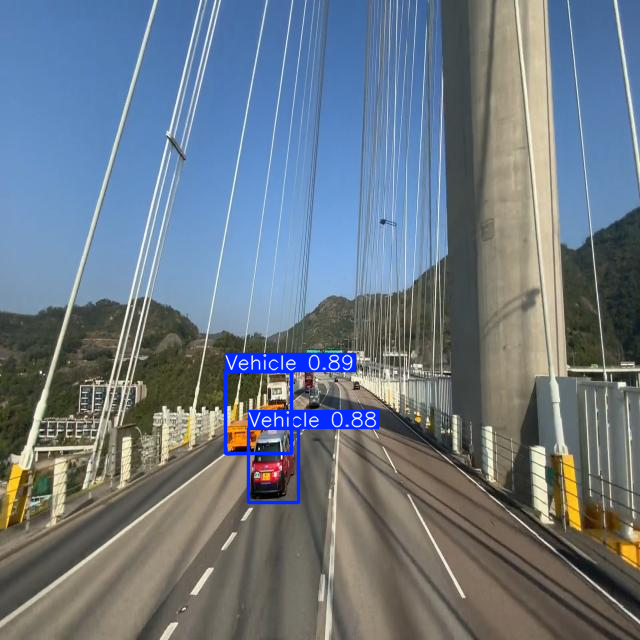


✅ Found 2 vehicle(s) with confidence > 0.5:
  Vehicle 1: 225,371 → 291,453  (conf: 0.89)
  Vehicle 2: 248,428 → 298,502  (conf: 0.88)

📁 Annotated image saved to: /content/random_detected_image.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
import random
import glob

# Load model from Drive
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'
model = YOLO(model_path)
print("✅ Model loaded")

# Path to validation images
DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset'
images_dir = os.path.join(DATASET_DIR, 'valid', 'images')

# Find all image files (jpg, jpeg, png)
image_extensions = ['*.jpg', '*.jpeg', '*.png']
image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(images_dir, ext)))

if not image_files:
    print(f"❌ No image files found in {images_dir}")
    # Fallback: try train images
    images_dir = os.path.join(DATASET_DIR, 'train', 'images')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(images_dir, ext)))
    if not image_files:
        print("❌ No images found in train or valid folders.")
        exit()
    else:
        print(f"📁 Using train images (found {len(image_files)} files)")

else:
    print(f"📁 Found {len(image_files)} images in validation set.")

# Pick a random image
random_image_path = random.choice(image_files)
print(f"\n🎲 Randomly selected image: {os.path.basename(random_image_path)}")

# Run inference
results = model(random_image_path, conf=0.5)

# Get annotated image
annotated_img = results[0].plot()

# Display
print("\n🔍 Detection Result:")
cv2_imshow(annotated_img)

# Save output
output_image_path = '/content/random_detected_image.jpg'
cv2.imwrite(output_image_path, annotated_img)

# Print detection summary
detections = results[0].boxes
if detections is not None and len(detections) > 0:
    print(f"\n✅ Found {len(detections)} vehicle(s) with confidence > 0.5:")
    for i, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        print(f"  Vehicle {i+1}: {x1},{y1} → {x2},{y2}  (conf: {conf:.2f})")
else:
    print("\n⚠️ No vehicles detected in this random image.")

print(f"\n📁 Annotated image saved to: {output_image_path}")

# Download the image (optional)
from google.colab import files
files.download(output_image_path)

✅ Model loaded
📁 Found 90 images in validation set.

🎲 Randomly selected image: test2_mp4-1_jpg.rf.695e12d07d9427f18d33d1e69827075f.jpg

image 1/1 /content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset/valid/images/test2_mp4-1_jpg.rf.695e12d07d9427f18d33d1e69827075f.jpg: 640x640 17 Vehicles, 224.3ms
Speed: 4.6ms preprocess, 224.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

🔍 Detection Result:


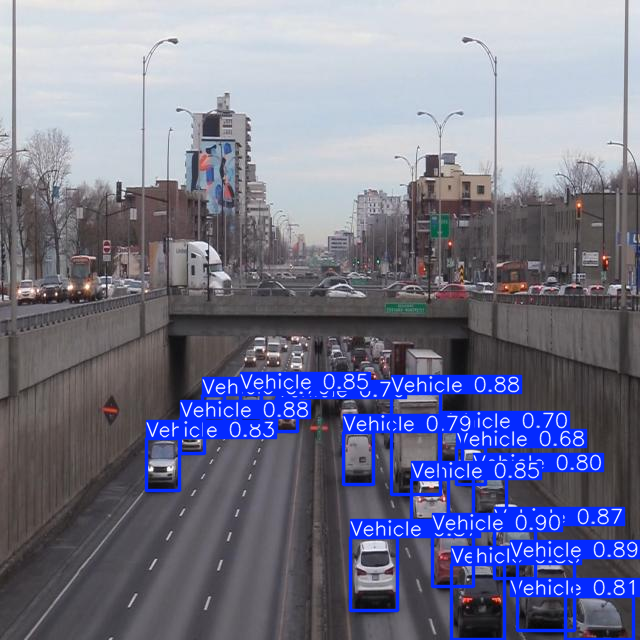


✅ Found 17 vehicle(s) with confidence > 0.5:
  Vehicle 1: 432,531 → 473,586  (conf: 0.90)
  Vehicle 2: 517,558 → 574,630  (conf: 0.89)
  Vehicle 3: 180,418 → 204,453  (conf: 0.88)
  Vehicle 4: 391,393 → 440,494  (conf: 0.88)
  Vehicle 5: 451,564 → 504,639  (conf: 0.88)
  Vehicle 6: 350,537 → 397,610  (conf: 0.87)
  Vehicle 7: 494,525 → 535,578  (conf: 0.87)
  Vehicle 8: 411,479 → 448,530  (conf: 0.85)
  Vehicle 9: 240,390 → 261,422  (conf: 0.85)
  Vehicle 10: 146,438 → 179,490  (conf: 0.83)
  Vehicle 11: 565,596 → 633,639  (conf: 0.81)
  Vehicle 12: 473,471 → 506,515  (conf: 0.80)
  Vehicle 13: 343,432 → 373,484  (conf: 0.79)
  Vehicle 14: 202,395 → 224,424  (conf: 0.79)
  Vehicle 15: 276,398 → 297,431  (conf: 0.76)
  Vehicle 16: 439,429 → 462,464  (conf: 0.70)
  Vehicle 17: 456,447 → 485,484  (conf: 0.68)

📁 Annotated image saved to: /content/random_detected_image.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
import random
import glob

# Load model from Drive
model_path = '/content/drive/MyDrive/vehicle_detection_project/runs/detect/vehicle_detector/weights/best.pt'
model = YOLO(model_path)
print("✅ Model loaded")

# Path to validation images
DATASET_DIR = '/content/drive/MyDrive/vehicle_detection_project/dataset/Vehicle_Detection_Image_Dataset'
images_dir = os.path.join(DATASET_DIR, 'valid', 'images')

# Find all image files (jpg, jpeg, png)
image_extensions = ['*.jpg', '*.jpeg', '*.png']
image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(images_dir, ext)))

if not image_files:
    print(f"❌ No image files found in {images_dir}")
    # Fallback: try train images
    images_dir = os.path.join(DATASET_DIR, 'train', 'images')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(images_dir, ext)))
    if not image_files:
        print("❌ No images found in train or valid folders.")
        exit()
    else:
        print(f"📁 Using train images (found {len(image_files)} files)")

else:
    print(f"📁 Found {len(image_files)} images in validation set.")

# Pick a random image
random_image_path = random.choice(image_files)
print(f"\n🎲 Randomly selected image: {os.path.basename(random_image_path)}")

# Run inference
results = model(random_image_path, conf=0.5)

# Get annotated image
annotated_img = results[0].plot()

# Display
print("\n🔍 Detection Result:")
cv2_imshow(annotated_img)

# Save output
output_image_path = '/content/random_detected_image.jpg'
cv2.imwrite(output_image_path, annotated_img)

# Print detection summary
detections = results[0].boxes
if detections is not None and len(detections) > 0:
    print(f"\n✅ Found {len(detections)} vehicle(s) with confidence > 0.5:")
    for i, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        print(f"  Vehicle {i+1}: {x1},{y1} → {x2},{y2}  (conf: {conf:.2f})")
else:
    print("\n⚠️ No vehicles detected in this random image.")

print(f"\n📁 Annotated image saved to: {output_image_path}")

# Download the image (optional)
from google.colab import files
files.download(output_image_path)